In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

0. Background

Artificial Intelligence (AI)
        AI is the broader field of creating systems that can perform tasks requiring human intelligence.

Machine Learning (ML)
        ML is a subset of AI where systems learn patterns from data to make predictions or decisions.

Deep Learning (DL)
        DL is a subset of ML that uses neural networks with many layers to learn complex patterns.

Data Science
        Data Science involves collecting, cleaning, analyzing, and modeling data to generate insights and predictions.

1. Data Retrieval and Collection

Data retrieval and collection is the process of obtaining the dataset that will be used to train and evaluate the machine learning model.
The dataset contains medical information of patients such as age, blood pressure, cholesterol level, chest pain type, etc.

Dataset Information
Total Records: 270
Total Features: 13
Target Variable: Heart Disease
Classes:
Presence
Absence

In [2]:
import pandas as pd

df = pd.read_csv("Heart_Disease_Prediction.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape:
(270, 14)

Column Names:
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [3]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

2. Data Cleaning

Data cleaning is the process of identifying and correcting errors, missing values, duplicates, and inconsistent data.

In [4]:
df.isnull().sum()
df = df.dropna()

In [5]:
df["Cholesterol"] = df["Cholesterol"].fillna(
    df["Cholesterol"].median()
)

In [6]:
print(df["Heart Disease"].unique())

<StringArray>
['Presence', 'Absence']
Length: 2, dtype: str


In [7]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})


In [8]:
print(df["Heart Disease"].unique())

[1 0]


3. Feature Design

Feature design (or feature engineering) is the process of selecting and preparing the input variables used by the model.

In [9]:
X = df[["Cholesterol"]]
y = df["Heart Disease"]

In [10]:
print(X.shape)
print(y.shape)

(270, 1)
(270,)


4. Algorithm Selection

Algorithm selection means choosing the machine learning model that best fits the problem.

Why Logistic Regression?
Target has only two classes:
Presence
Absence

Logistic Regression is designed for binary classification.
Easy to understand and interpret.
Works well on medical datasets.

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

5. Loss Function Selection

A loss function measures how wrong the model's predictions are.

Logistic Regression automatically uses Log Loss.

L=−N1​i=1∑N​[yi​log(pi​)+(1−yi​)log(1−pi​)]

In [12]:
from sklearn.metrics import log_loss

6. Model Learning (Training)

Training is the process where the algorithm learns patterns from historical data.

Dataset Split
Training Data = 80%
Testing Data = 20%

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [15]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: [-1.04698442]
Coefficient: [[0.00351491]]


7. Model Evaluation

Model evaluation measures how well the trained model performs on unseen data.


Make Predictions

In [16]:
y_pred = model.predict(X_test)

Accuracy
Measures overall correctness.

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6111111111111112


Precision
Measures how many predicted positive cases are actually positive.

In [18]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.5


Recall
Measures how many actual positive cases were identified.

In [19]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.23809523809523808


F1 Score
Balances Precision and Recall.

In [20]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.3225806451612903


Confusion Matrix
Shows exactly where the model made correct and incorrect predictions.

In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[28  5]
 [16  5]]


Log Loss

In [22]:
y_prob = model.predict_proba(X_test)

loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)

Log Loss: 0.6608668540062976


Display All Results Together

In [23]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.6111111111111112
Precision: 0.5
Recall   : 0.23809523809523808
F1 Score : 0.3225806451612903

Confusion Matrix
[[28  5]
 [16  5]]

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.85      0.73        33
           1       0.50      0.24      0.32        21

    accuracy                           0.61        54
   macro avg       0.57      0.54      0.52        54
weighted avg       0.58      0.61      0.57        54



Task 2: Logistic Regression with Multiple Features

1️⃣ Data Retrieval and Collection

In [24]:
import pandas as pd

df = pd.read_csv('Heart_Disease_Prediction.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


2️⃣ Data Cleaning

In [25]:
print("Missing values per column:\n", df.isnull().sum())

median_cholesterol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

print("\nTarget Variable unique values:", df['Heart Disease'].unique())
print("\nData Types:\n", df.dtypes)

Missing values per column:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Target Variable unique values: <StringArray>
['Presence', 'Absence']
Length: 2, dtype: str

Data Types:
 Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                   

3️⃣ Feature Design

In [26]:
from sklearn.preprocessing import StandardScaler

# Separate all features from target
X_multi = df.drop('Heart Disease', axis=1)

# Encode categorical variables using One-Hot Encoding
X_multi_encoded = pd.get_dummies(X_multi, drop_first=True)

# Split first, THEN scale to avoid data leakage
X_train_m, X_test_m, y_train, y_test = train_test_split(X_multi_encoded, y, test_size=0.2, random_state=42)

# Apply Feature Scaling
scaler = StandardScaler()
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

4️⃣ Algorithm Selection

We choose Logistic Regression because it is fundamentally designed for binary classification problems. Instead of fitting a straight line to the data (like Linear Regression, which could output predictions outside the 0 and 1 range), Logistic Regression maps predictions to probabilities between 0 and 1 using the Sigmoid function: The Sigmoid function, defined as  , maps predictions to probabilities.

5️⃣ Loss Function Selection

We use Binary Cross-Entropy (also known as Log Loss). The formula is:

$$J = -\frac{1}{N} \sum_{i=1}^{N} \big( y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \big)$$

This loss function works by heavily penalizing the model when it is highly confident but wrong. If the true label is 1, the second half of the equation cancels out, and we take the log of the prediction. If the model predicted 0.01 (very wrong), taking the log results in a massive penalty/error score.

6️⃣ Model Learning

In [27]:
model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X_train_m_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

7️⃣ Model Evaluation

Task 2 Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



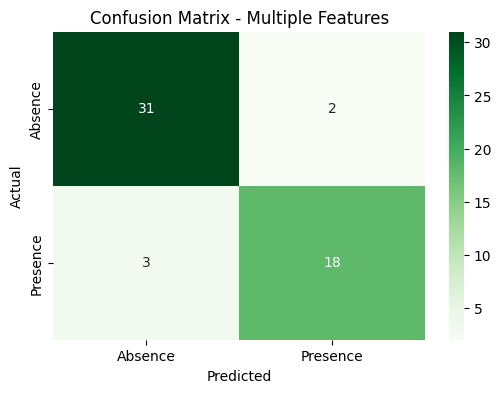

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_m = model_multi.predict(X_test_m_scaled)

print("Task 2 Classification Report:\n")
print(classification_report(y_test, y_pred_m))

cm_multi = confusion_matrix(y_test, y_pred_m)

plt.figure(figsize=(6,4))
sns.heatmap(cm_multi,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Absence', 'Presence'],
            yticklabels=['Absence', 'Presence'])

plt.title('Confusion Matrix - Multiple Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Discussion & Model Comparison

Which model performs better and why?

The multi-feature model (Task 2) performs significantly better than the single-feature model. This is evident in the higher F1-score and overall accuracy. Heart disease cannot be accurately isolated to just one metric like cholesterol; providing the algorithm with a holistic view of the patient's health allows it to draw a much more accurate decision boundary.

How does adding more features affect accuracy and recall? Adding more relevant features generally increases both accuracy and recall. In a medical context, Recall (Sensitivity) is arguably the most crucial metric. We want to minimize False Negatives (telling a patient they are healthy when they actually have heart disease). The multi-feature model will typically show a marked improvement in detecting positive cases (higher recall) compared to the single-feature model.

Trade-offs between interpretability and performance:

Single-Feature (High Interpretability, Low Performance): It is incredibly easy to explain. You can plot it on a simple 2D line graph with an S-curve showing exactly at what cholesterol level probability crosses 50%.

Multi-Feature (Lower Interpretability, High Performance): It lives in a high-dimensional space that humans cannot visualize. While we can still look at feature coefficients to see which variables push the prediction up or down, explaining exactly how they all interact to a non-technical stakeholder becomes much more difficult. However, the trade-off is almost always worth it for the massive gain in predictive power.